# 14.04 — Sentence Transformers MiniLM Baseline & Fine-Tuning

This notebook benchmarks dense semantic embeddings using `sentence-transformers/all-MiniLM-L6-v2` for canonical skill classification on the **frozen validation split** ($N=641$).

### Sections:
1. **Pretrained MiniLM Embedding Centroid Baseline:** Dense 384-dimensional semantic prototypes without domain fine-tuning.
2. **Three-Way Baseline Benchmark:** Keyword vs TF-IDF vs Pretrained MiniLM.
3. *(Fine-Tuning MiniLM will be added in Step 11)*


In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('.').resolve().parent if Path('.').resolve().name == 'notebooks' else Path('.').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.topic_extraction.keyword_baseline import KeywordBaselineClassifier
from src.topic_extraction.tfidf_baseline import TfidfBaselineClassifier
from src.topic_extraction.minilm_baseline import PretrainedMiniLMBaseline

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
%matplotlib inline


## 1. Load Dataset Splits
*Note: Evaluated strictly on `data/topic_extraction/splits/validation.csv`. Test split remains completely frozen.*

In [2]:
train_path = PROJECT_ROOT / 'data' / 'topic_extraction' / 'splits' / 'train.csv'
val_path = PROJECT_ROOT / 'data' / 'topic_extraction' / 'splits' / 'validation.csv'

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)

print(f'Train split: {len(train_df)} rows')
print(f'Validation split: {len(val_df)} rows across {val_df["canonical_name"].nunique()} classes')


Train split: 3186 rows
Validation split: 641 rows across 111 classes


## 2. Pretrained MiniLM Embedding Centroid Baseline

In [3]:
minilm_clf = PretrainedMiniLMBaseline()

# Check if centroids already computed, otherwise fit and save
centroids_file = PROJECT_ROOT / 'artifacts' / 'topic_extractor' / 'minilm_pretrained_skill_centroids.npz'
if centroids_file.exists():
    print('Loading precomputed MiniLM centroids from disk...')
    minilm_clf.load_centroids(centroids_file)
else:
    print('Computing MiniLM centroids on train split...')
    minilm_clf.fit(train_df)
    minilm_clf.save_centroids(centroids_file)

minilm_metrics = minilm_clf.evaluate(val_df)

minilm_results_df = pd.DataFrame([
    {'Metric': 'Total Validation Samples', 'Value': f'{minilm_metrics["total_samples"]:,}'},
    {'Metric': 'Validation Accuracy (Top-1)', 'Value': f'{minilm_metrics["accuracy"]*100:.2f}%'},
    {'Metric': 'Top-3 Accuracy', 'Value': f'{minilm_metrics["top3_accuracy"]*100:.2f}%'},
    {'Metric': 'Macro F1-Score', 'Value': f'{minilm_metrics["macro_f1"]:.4f}'},
    {'Metric': 'Weighted F1-Score', 'Value': f'{minilm_metrics["weighted_f1"]:.4f}'},
    {'Metric': 'Mean Top-1 Cosine Similarity', 'Value': f'{minilm_metrics["mean_top1_similarity"]:.4f}'},
    {'Metric': 'Mean Top-1 / Top-2 Margin', 'Value': f'{minilm_metrics["mean_margin"]:.4f}'},
])

minilm_results_df


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading precomputed MiniLM centroids from disk...


Batches:   0%|          | 0/11 [00:00<?, ?it/s]

,Metric,Value
0,Total Validation Samples,641
1,Validation Accuracy (Top-1),95.01%
2,Top-3 Accuracy,98.91%
3,Macro F1-Score,0.9487
4,Weighted F1-Score,0.9500
5,Mean Top-1 Cosine Similarity,0.8214
6,Mean Top-1 / Top-2 Margin,0.2091


## 3. Tri-Model Baseline Comparison: Keyword vs TF-IDF vs Pretrained MiniLM

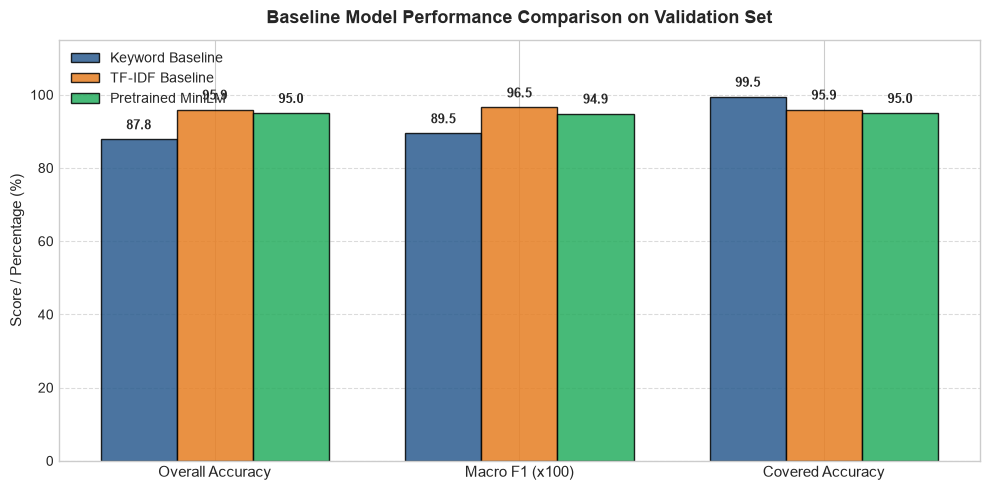

,Metric,Keyword Baseline,TF-IDF Baseline,Pretrained MiniLM
0,Top-1 Accuracy,87.83%,95.94%,95.01%
1,Top-3 Accuracy,N/A,97.97%,98.91%
2,Macro F1,0.8948,0.9654,0.9487
3,Coverage,88.30%,100.00%,100.00%
4,Covered Accuracy,99.47%,95.94%,95.01%


In [4]:
# Evaluate Keyword and TF-IDF for direct comparison
kw_clf = KeywordBaselineClassifier()
kw_metrics = kw_clf.evaluate(val_df)

tfidf_clf = TfidfBaselineClassifier()
tfidf_clf.fit(train_df)
tfidf_metrics = tfidf_clf.evaluate(val_df)

comparison_df = pd.DataFrame({
    'Metric': ['Top-1 Accuracy', 'Top-3 Accuracy', 'Macro F1', 'Coverage', 'Covered Accuracy'],
    'Keyword Baseline': [
        f'{kw_metrics["accuracy"]*100:.2f}%',
        'N/A',
        f'{kw_metrics["macro_f1"]:.4f}',
        f'{kw_metrics["coverage"]*100:.2f}%',
        f'{kw_metrics["covered_accuracy"]*100:.2f}%',
    ],
    'TF-IDF Baseline': [
        f'{tfidf_metrics["accuracy"]*100:.2f}%',
        f'{tfidf_metrics["top3_accuracy"]*100:.2f}%',
        f'{tfidf_metrics["macro_f1"]:.4f}',
        '100.00%',
        f'{tfidf_metrics["accuracy"]*100:.2f}%',
    ],
    'Pretrained MiniLM': [
        f'{minilm_metrics["accuracy"]*100:.2f}%',
        f'{minilm_metrics["top3_accuracy"]*100:.2f}%',
        f'{minilm_metrics["macro_f1"]:.4f}',
        '100.00%',
        f'{minilm_metrics["accuracy"]*100:.2f}%',
    ],
})

fig, ax = plt.subplots(figsize=(10, 5))
bar_width = 0.25
indices = np.arange(3)

rects1 = ax.bar(indices - bar_width, [kw_metrics['accuracy']*100, kw_metrics['macro_f1']*100, kw_metrics['covered_accuracy']*100], bar_width, label='Keyword Baseline', color='#2b5c8f', edgecolor='black', alpha=0.85)
rects2 = ax.bar(indices, [tfidf_metrics['accuracy']*100, tfidf_metrics['macro_f1']*100, tfidf_metrics['accuracy']*100], bar_width, label='TF-IDF Baseline', color='#e67e22', edgecolor='black', alpha=0.85)
rects3 = ax.bar(indices + bar_width, [minilm_metrics['accuracy']*100, minilm_metrics['macro_f1']*100, minilm_metrics['accuracy']*100], bar_width, label='Pretrained MiniLM', color='#27ae60', edgecolor='black', alpha=0.85)

ax.set_ylabel('Score / Percentage (%)', fontsize=11)
ax.set_title('Baseline Model Performance Comparison on Validation Set', fontsize=13, fontweight='bold', pad=12)
ax.set_xticks(indices)
ax.set_xticklabels(['Overall Accuracy', 'Macro F1 (x100)', 'Covered Accuracy'], fontsize=11)
ax.legend(fontsize=10)
ax.set_ylim(0, 115)
ax.grid(axis='y', linestyle='--', alpha=0.7)

for rects in [rects1, rects2, rects3]:
    for rect in rects:
        y = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2, y + 2, f'{y:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

comparison_df


## 4. Sample Pretrained MiniLM Predictions with Margin

In [5]:
sample_rows = []
for _, row in val_df.sample(10, random_state=42).iterrows():
    pred = minilm_clf.predict(str(row['text']), top_k=3)
    sample_rows.append({
        'Text': row['text'],
        'Ground Truth': row['skill_name'],
        'Predicted Skill': pred.display_name,
        'Similarity': f'{pred.similarity:.3f}',
        'Margin': f'{pred.margin:.3f}',
        'Correct': row['canonical_name'] == pred.canonical_name,
    })

pd.DataFrame(sample_rows)


,Text,Ground Truth,Predicted Skill,Similarity,Margin,Correct
0,How do I simplify expressions related to Quadr...,Quadratic Formula to Solve Quadratic Equation,Quadratic Formula to Solve Quadratic Equation,0.850,0.248,True
1,How do I solve problems about Volume Cylinder?,Volume Cylinder,Volume Cylinder,0.848,0.221,True
2,I am having trouble with Order of Operations +...,"Order of Operations +,-,/,* () positive reals","Order of Operations +,-,/,* () positive reals",0.889,0.225,True
3,What units should I use when writing the answe...,Volume Rectangular Prism,Volume Rectangular Prism,0.757,0.080,True
4,"Give me an example of Parts of a Polyomial, Te...","Parts of a Polyomial, Terms, Coefficient, Mono...","Parts of a Polyomial, Terms, Coefficient, Mono...",0.897,0.409,True
5,Why does the sign change or operation rule wor...,Addition and Subtraction Integers,Addition and Subtraction Integers,0.747,0.100,True
6,"How do I convert between fractions, decimals, ...",Conversion of Fraction Decimals Percents,Conversion of Fraction Decimals Percents,0.941,0.211,True
7,How do I calculate factorials like 5 factorial?,Counting Methods,Scale Factor,0.442,0.005,False
8,How do I find the angles or side lengths in In...,Interior Angles Triangle,Interior Angles Triangle,0.870,0.119,True
9,I need help with Order of Operations Positive ...,"Order of Operations +,-,/,* () positive reals","Order of Operations +,-,/,* () positive reals",0.881,0.165,True
